# Orbit Propagator

Step 1: Load cached ESTCUBE-1 TLE or download once

In [24]:
from pathlib import Path
from urllib.request import urlopen

# ESTCUBE-1 (NORAD ID 39161)
TLE_URL = 'http://celestrak.org/NORAD/elements/gp.php?CATNR=39161&FORMAT=TLE'
TLE_FILE = Path('data/estcube_39161.tle')

def load_or_download_tle() -> str:
    TLE_FILE.parent.mkdir(parents=True, exist_ok=True)

    if TLE_FILE.exists():
        print(f"Using cached file: {TLE_FILE}")
    else:
        print("Downloading ESTCUBE-1 TLE...")
        with urlopen(TLE_URL, timeout=30) as response:
            text = response.read().decode("utf-8", errors="replace")
        TLE_FILE.write_text(text, encoding="utf-8")
        print(f"Saved to: {TLE_FILE}")

    return TLE_FILE.read_text(encoding="utf-8", errors="replace")

tle_text = load_or_download_tle()
print("\nPreview:")
print("\n".join(tle_text.splitlines()[:3]))


Using cached file: data/estcube_39161.tle

Preview:
ESTCUBE 1               
1 39161U 13021C   26112.12892051  .00001110  00000+0  14891-3 0  9995
2 39161  97.7342 168.2770 0008051 187.9450 172.1636 14.81225531696721


Step 2: Extract and print TLE orbital parameters

In [25]:
from datetime import datetime, timedelta, timezone
from math import radians

def tle_epoch_to_datetime(epoch_text: str) -> datetime:
    year = int(epoch_text[:2])
    day_of_year = float(epoch_text[2:])
    full_year = 2000 + year if year < 57 else 1900 + year
    return datetime(full_year, 1, 1, tzinfo=timezone.utc) + timedelta(days=day_of_year - 1)

def parse_tle_parameters(tle_text: str) -> dict[str, float | datetime]:
    lines = [line.strip() for line in tle_text.splitlines() if line.strip()]
    line1 = lines[1]
    line2 = lines[2]

    return {
        "epoch": tle_epoch_to_datetime(line1[18:32]),
        "inclination_rad": radians(float(line2[8:16])),
        "raan_rad": radians(float(line2[17:25])),
        "eccentricity": float(f"0.{line2[26:33].strip()}"),
        "argument_of_periapsis_rad": radians(float(line2[34:42])),
        "mean_anomaly_rad": radians(float(line2[43:51])),
        "mean_motion_rev_per_day": float(line2[52:63]),
    }

tle_parameters = parse_tle_parameters(tle_text)

print("Selected satellite TLE parameters:")
print(f"Epoch: {tle_parameters['epoch'].strftime('%Y-%m-%d %H:%M:%S.%f UTC')}")
print(f"Inclination: {tle_parameters['inclination_rad']:.10f} rad")
print(f"RAAN: {tle_parameters['raan_rad']:.10f} rad")
print(f"Eccentricity: {tle_parameters['eccentricity']:.10f}")
print(f"Argument of periapsis: {tle_parameters['argument_of_periapsis_rad']:.10f} rad")
print(f"Mean anomaly: {tle_parameters['mean_anomaly_rad']:.10f} rad")
print(f"Mean motion: {tle_parameters['mean_motion_rev_per_day']:.8f} rev/day")


Selected satellite TLE parameters:
Epoch: 2026-04-22 03:05:38.732064 UTC
Inclination: 1.7057835818 rad
RAAN: 2.9369877054 rad
Eccentricity: 0.0008051000
Argument of periapsis: 3.2802590627 rad
Mean anomaly: 3.0048216721 rad
Mean motion: 14.81225531 rev/day


Step 3: Propagate the orbit to **2026-04-24 17:00:00**.

In [26]:
target_time = datetime(2026, 4, 24, 17, 0, 0, tzinfo=timezone.utc)
tle_epoch = tle_parameters["epoch"]

# Propagation time: Dt = t - t0
delta_t = target_time - tle_epoch
delta_t_seconds = delta_t.total_seconds()
delta_t_days = delta_t_seconds / (24 * 60 * 60)

print("Propagation time:")
print(f"t0 (TLE epoch): {tle_epoch.strftime('%Y-%m-%d %H:%M:%S.%f UTC')}")
print(f"t  (target):    {target_time.strftime('%Y-%m-%d %H:%M:%S UTC')}")
print(f"Dt: {delta_t}")
print(f"Dt: {delta_t_seconds:.6f} seconds")
print(f"Dt: {delta_t_days:.10f} solar days")


Propagation time:
t0 (TLE epoch): 2026-04-22 03:05:38.732064 UTC
t  (target):    2026-04-24 17:00:00 UTC
Dt: 2 days, 13:54:21.267936
Dt: 222861.267936 seconds
Dt: 2.5794128233 solar days


In [27]:
from math import degrees, floor

M0_deg = degrees(tle_parameters["mean_anomaly_rad"])
n = tle_parameters["mean_motion_rev_per_day"]

# Mean anomaly at time t:
# M(t) = M0 + 360 * { nDt - INT(nDt) - INT([M0 + 360(nDt - INT(nDt))] / 360) }

completed_orbits = floor(n * delta_t_days)
fractional_orbit = n * delta_t_days - completed_orbits
wrap_count = floor((M0_deg + 360 * fractional_orbit) / 360) # check if fractional part of M(t) exceeds 360 degrees

mean_anomaly_t_deg = M0_deg + 360 * (fractional_orbit - wrap_count)
mean_anomaly_t_rad = radians(mean_anomaly_t_deg)

print("Mean anomaly at target time:")
print(f"M(t): {mean_anomaly_t_rad:.10f} rad")


Mean anomaly at target time:
M(t): 4.3049464755 rad


In [28]:
from math import cos, sin

# Newton method
def solve_kepler_equation(mean_anomaly_rad: float, eccentricity: float, tolerance: float = 1e-12, max_iterations: int = 50) -> float:
    E = mean_anomaly_rad

    for _ in range(max_iterations):
        residual = E - eccentricity * sin(E) - mean_anomaly_rad
        slope = 1 - eccentricity * cos(E) # dM/dE = 1 - e cos(E)
        correction = residual / slope
        E -= correction

        if abs(correction) < tolerance:
            return E

    raise RuntimeError("Kepler equation solver did not converge")

eccentricity = tle_parameters["eccentricity"]
eccentric_anomaly_t_rad = solve_kepler_equation(mean_anomaly_t_rad, eccentricity)

print("Eccentric anomaly at target time:")
print(f"E(t): {eccentric_anomaly_t_rad:.10f} rad")

Eccentric anomaly at target time:
E(t): 4.3042075192 rad


In [29]:
from math import atan2, sqrt, pi

# True anomaly from eccentric anomaly:
# cos(nu) = (cos(E) - e) / (1 - e cos(E))
# sin(nu) = sqrt(1 - e^2) sin(E) / (1 - e cos(E))

cos_true_anomaly = (cos(eccentric_anomaly_t_rad) - eccentricity) / (1 - eccentricity * cos(eccentric_anomaly_t_rad))
sin_true_anomaly = (sqrt(1 - eccentricity**2) * sin(eccentric_anomaly_t_rad)) / (1 - eccentricity * cos(eccentric_anomaly_t_rad))

# for quadrant safe angle calculation
true_anomaly_t_rad = atan2(sin_true_anomaly, cos_true_anomaly)
if true_anomaly_t_rad < 0:
    true_anomaly_t_rad += 2 * pi

print("True anomaly at target time:")
print(f"nu(t): {true_anomaly_t_rad:.10f} rad")

True anomaly at target time:
nu(t): 4.3034686808 rad


In [30]:
# Semi-major axis from mean motion using Kepler's third law
# a = [mu / (2*pi*n)^2]^(1/3), with n in orbits/day and mu in km^3/day^2
mu_earth_km3_day2 = 2.97554e15
mean_motion_rev_day = tle_parameters["mean_motion_rev_per_day"]

semi_major_axis_km = (mu_earth_km3_day2 / (2 * pi * mean_motion_rev_day) ** 2) ** (1 / 3)

print("Semi-major axis:")
print(f"a: {semi_major_axis_km:.6f} km")


Semi-major axis:
a: 7003.598257 km


In [31]:
# Perigee distance
perigee_distance_km = semi_major_axis_km * (1 - eccentricity)

print("Perigee distance:")
print(f"P: {perigee_distance_km:.6f} km")


Perigee distance:
P: 6997.959660 km


In [32]:
# Orbital period from mean motion
orbital_period_days = 1 / mean_motion_rev_day
orbital_period_minutes = orbital_period_days * 24 * 60

print("Orbital period:")
print(f"T: {orbital_period_minutes:.6f} minutes")


Orbital period:
T: 97.216796 minutes


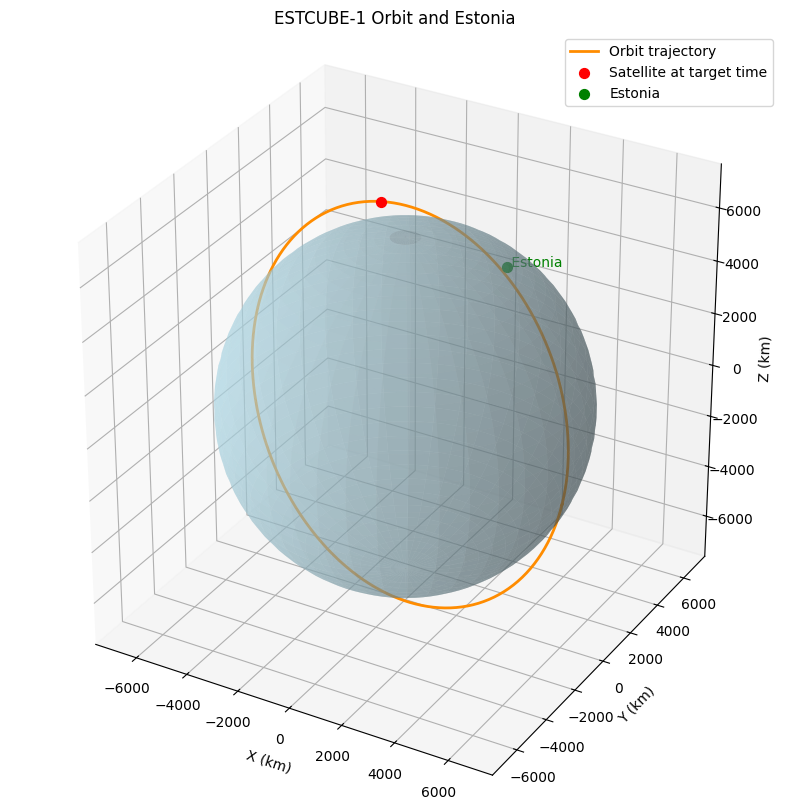

In [34]:

import matplotlib.pyplot as plt
import numpy as np


earth_radius_km = 6378.137

inclination = tle_parameters["inclination_rad"]
raan = tle_parameters["raan_rad"]
argument_of_periapsis = tle_parameters["argument_of_periapsis_rad"]

true_anomaly_samples = np.linspace(0, 2 * np.pi, 500)
radius_samples = semi_major_axis_km * (1 - eccentricity**2) / (1 + eccentricity * np.cos(true_anomaly_samples))

x_perifocal = radius_samples * np.cos(true_anomaly_samples)
y_perifocal = radius_samples * np.sin(true_anomaly_samples)
z_perifocal = np.zeros_like(x_perifocal)

# Rotate from perifocal coordinates into ECIF
cos_raan = np.cos(raan)
sin_raan = np.sin(raan)
cos_i = np.cos(inclination)
sin_i = np.sin(inclination)
cos_w = np.cos(argument_of_periapsis)
sin_w = np.sin(argument_of_periapsis)

rotation_matrix = np.array([
    [cos_raan * cos_w - sin_raan * sin_w * cos_i, -cos_raan * sin_w - sin_raan * cos_w * cos_i, sin_raan * sin_i],
    [sin_raan * cos_w + cos_raan * sin_w * cos_i, -sin_raan * sin_w + cos_raan * cos_w * cos_i, -cos_raan * sin_i],
    [sin_w * sin_i, cos_w * sin_i, cos_i],
])

orbit_xyz = rotation_matrix @ np.vstack((x_perifocal, y_perifocal, z_perifocal))
radius_now_km = semi_major_axis_km * (1 - eccentricity**2) / (1 + eccentricity * np.cos(true_anomaly_t_rad))
position_perifocal_now = np.array([
    radius_now_km * np.cos(true_anomaly_t_rad),
    radius_now_km * np.sin(true_anomaly_t_rad),
    0.0,
])
satellite_xyz = rotation_matrix @ position_perifocal_now

# Estonia marker on a simple Earth-fixed globe
estonia_lat_deg = 58.5953
estonia_lon_deg = 25.0136
estonia_lat = np.radians(estonia_lat_deg)
estonia_lon = np.radians(estonia_lon_deg)

estonia_xyz = earth_radius_km * np.array([
    np.cos(estonia_lat) * np.cos(estonia_lon),
    np.cos(estonia_lat) * np.sin(estonia_lon),
    np.sin(estonia_lat),
])

# Earth sphere
u = np.linspace(0, 2 * np.pi, 80)
v = np.linspace(0, np.pi, 40)
x_earth = earth_radius_km * np.outer(np.cos(u), np.sin(v))
y_earth = earth_radius_km * np.outer(np.sin(u), np.sin(v))
z_earth = earth_radius_km * np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x_earth, y_earth, z_earth, color='lightblue', alpha=0.45, linewidth=0)
ax.plot(orbit_xyz[0], orbit_xyz[1], orbit_xyz[2], color='darkorange', linewidth=2, label='Orbit trajectory')
ax.scatter(*satellite_xyz, color='red', s=50, label='Satellite at target time')
ax.scatter(*estonia_xyz, color='green', s=50, label='Estonia')
ax.text(*estonia_xyz, ' Estonia', color='green')

axis_limit = max(float(np.max(np.abs(orbit_xyz))), earth_radius_km) * 1.1
ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)
ax.set_zlim(-axis_limit, axis_limit)
ax.set_box_aspect([1, 1, 1])

ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.set_title('ESTCUBE-1 Orbit and Estonia')
ax.legend()
plt.show()
